# **Imports**

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import time
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# **Load Dataset**

In [3]:
df = pd.read_csv("raw_dataset.csv")

In [4]:
df.head()

,text,label
0,Artificial intelligence (AI) is intelligence d...,Artificial Intelligence
1,Machine learning is a field of artificial inte...,Artificial Intelligence
2,Deep learning is a subset of machine learning ...,Artificial Intelligence
3,A neural network is a computational model insp...,Artificial Intelligence
4,Natural language processing is a branch of AI ...,Artificial Intelligence


In [5]:
df.shape

(60, 2)

In [6]:
df['label'].value_counts()

,count
label,
Artificial Intelligence,15
Space Exploration,15
Human Biology,15
Famous Scientists,15


# **Cleaning Functions**

In [7]:
from bs4 import BeautifulSoup

In [8]:
def remove_html_tags(text):
    return BeautifulSoup(text, "html.parser").get_text()

In [9]:
def remove_citations(text):
    return re.sub(r'\[\d+\]', '', text)

In [10]:
def remove_punctuation(text):
    return re.sub(r'[^a-zA-Z0-9\s]', '', text)

In [11]:
def to_lowercase(text):
    return text.lower()

In [12]:
def remove_extra_spaces(text):
    return re.sub(r'\s+', ' ', text).strip()

In [13]:
def full_clean(text):
    text = remove_html_tags(text)
    text = remove_citations(text)
    text = remove_punctuation(text)
    text = to_lowercase(text)
    text = remove_extra_spaces(text)
    return text

In [14]:
full_clean(df['text'][0])

'artificial intelligence ai is intelligence demonstrated by machines as opposed to natural intelligence displayed by humans ai research has been defined as the field of study of intelligent agents which perceive their environment and take actions to maximize chance of achieving goals applications include web search engines recommendation systems understanding human speech selfdriving cars and generative tools ai was founded as an academic discipline in 1956 machine learning and deep learning are subfields that have driven recent progress ai systems are now used in healthcare finance education and defense the turing test proposed by alan turing in 1950 remains a benchmark for machine intelligence modern ai includes symbolic ai connectionist ai and hybrid approaches'

In [15]:
sample = df['text'][0][:400]

In [16]:
print("ORIGINAL:")
print(sample)

ORIGINAL:
Artificial intelligence (AI) is intelligence demonstrated by machines, as opposed to natural intelligence displayed by humans. AI research has been defined as the field of study of intelligent agents which perceive their environment and take actions to maximize chance of achieving goals. Applications include web search engines, recommendation systems, understanding human speech, self-driving cars,


In [17]:
s1 = remove_html_tags(sample)
print("AFTER remove_html_tags:")
print(s1[:300])

AFTER remove_html_tags:
Artificial intelligence (AI) is intelligence demonstrated by machines, as opposed to natural intelligence displayed by humans. AI research has been defined as the field of study of intelligent agents which perceive their environment and take actions to maximize chance of achieving goals. Application


In [18]:
s2 = remove_citations(s1)
print("AFTER remove_citations:")
print(s2[:300])

AFTER remove_citations:
Artificial intelligence (AI) is intelligence demonstrated by machines, as opposed to natural intelligence displayed by humans. AI research has been defined as the field of study of intelligent agents which perceive their environment and take actions to maximize chance of achieving goals. Application


In [19]:
s3 = remove_punctuation(s2)
print("AFTER remove_punctuation:")
print(s3[:300])

AFTER remove_punctuation:
Artificial intelligence AI is intelligence demonstrated by machines as opposed to natural intelligence displayed by humans AI research has been defined as the field of study of intelligent agents which perceive their environment and take actions to maximize chance of achieving goals Applications inc


In [20]:
s4 = to_lowercase(s3)
print("AFTER lowercase:")
print(s4[:300])

AFTER lowercase:
artificial intelligence ai is intelligence demonstrated by machines as opposed to natural intelligence displayed by humans ai research has been defined as the field of study of intelligent agents which perceive their environment and take actions to maximize chance of achieving goals applications inc


In [21]:
s5 = remove_extra_spaces(s4)
print("AFTER remove_extra_spaces:")
print(s5[:300])

AFTER remove_extra_spaces:
artificial intelligence ai is intelligence demonstrated by machines as opposed to natural intelligence displayed by humans ai research has been defined as the field of study of intelligent agents which perceive their environment and take actions to maximize chance of achieving goals applications inc


# **Apply Cleaning**

In [22]:
cleaned_df = df.copy()

In [23]:
cleaned_df['text'] = cleaned_df['text'].apply(full_clean)

In [24]:
cleaned_df.to_csv("cleaned_dataset.csv", index=False)

In [25]:
cleaned_df.head()

,text,label
0,artificial intelligence ai is intelligence dem...,Artificial Intelligence
1,machine learning is a field of artificial inte...,Artificial Intelligence
2,deep learning is a subset of machine learning ...,Artificial Intelligence
3,a neural network is a computational model insp...,Artificial Intelligence
4,natural language processing is a branch of ai ...,Artificial Intelligence


# **Tokenization**

In [26]:
cleaned_df['tokens'] = cleaned_df['text'].apply(word_tokenize)

In [27]:
print(f"Label: {cleaned_df['label'][0]}")
print(f"\nFirst 20 tokens:")
print(cleaned_df['tokens'][0][:20])
print(f"\nAvg tokens per article: {cleaned_df['tokens'].apply(len).mean():.0f}")

Label: Artificial Intelligence

First 20 tokens:
['artificial', 'intelligence', 'ai', 'is', 'intelligence', 'demonstrated', 'by', 'machines', 'as', 'opposed', 'to', 'natural', 'intelligence', 'displayed', 'by', 'humans', 'ai', 'research', 'has', 'been']

Avg tokens per article: 101


# **Remove Stopwords**

In [28]:
stop_words = set(stopwords.words('english'))
print(f"Total stopwords in NLTK: {len(stop_words)}")
print(f"Sample stopwords: {list(stop_words)[:15]}")

Total stopwords in NLTK: 198
Sample stopwords: ['have', 'with', 'few', 'hadn', "mustn't", 'shan', 'don', 'yours', 'did', 'we', 'for', 'itself', 'isn', "won't", 'has']


In [29]:
def remove_stopwords(tokens):
    return [t for t in tokens if t.lower() not in stop_words]

In [30]:
cleaned_df['tokens_no_stop'] = cleaned_df['tokens'].apply(remove_stopwords)

In [32]:
avg_before = cleaned_df['tokens'].apply(len).mean()
avg_after  = cleaned_df['tokens_no_stop'].apply(len).mean()
print(f"Avg tokens before stopword removal: {avg_before:.0f}")
print(f"Avg tokens after  stopword removal: {avg_after:.0f}")
print(f"Avg words removed per article: {avg_before - avg_after:.0f}")

Avg tokens before stopword removal: 101
Avg tokens after  stopword removal: 69
Avg words removed per article: 32


# **Stemming vs Lemmatization**

In [33]:
stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [35]:
cleaned_df['tokens_stemmed'] = cleaned_df['tokens_no_stop'].apply(
    lambda tokens: [stemmer.stem(t) for t in tokens])
cleaned_df['tokens_lemmatized'] = cleaned_df['tokens_no_stop'].apply(
    lambda tokens: [lemmatizer.lemmatize(t) for t in tokens])

In [36]:
# Compare 10 words side by side
sample_words = cleaned_df['tokens_no_stop'][0][:10]
print(f"{'Original':<20} {'Stemmed':<20} {'Lemmatized':<20}")
print("-" * 60)
for word in sample_words:
    print(f"{word:<20} {stemmer.stem(word):<20} {lemmatizer.lemmatize(word):<20}")

Original             Stemmed              Lemmatized          
------------------------------------------------------------
artificial           artifici             artificial          
intelligence         intellig             intelligence        
ai                   ai                   ai                  
intelligence         intellig             intelligence        
demonstrated         demonstr             demonstrated        
machines             machin               machine             
opposed              oppos                opposed             
natural              natur                natural             
intelligence         intellig             intelligence        
displayed            display              displayed           


# **Final clean_text Column**

In [37]:
cleaned_df['clean_text'] = cleaned_df['tokens_lemmatized'].apply(
    lambda t: ' '.join(t))
print("Sample clean_text:")
print(cleaned_df['clean_text'][0][:300])

Sample clean_text:
artificial intelligence ai intelligence demonstrated machine opposed natural intelligence displayed human ai research defined field study intelligent agent perceive environment take action maximize chance achieving goal application include web search engine recommendation system understanding human 


# **TF-IDF**

In [38]:
X = cleaned_df['clean_text']
y = cleaned_df['label']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [40]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)  # fit ONLY on train
X_test_tfidf  = tfidf.transform(X_test)       # only transform test

print(f"Train TF-IDF shape: {X_train_tfidf.shape}")
print(f"Test  TF-IDF shape: {X_test_tfidf.shape}")

Train TF-IDF shape: (48, 1671)
Test  TF-IDF shape: (12, 1671)


# **Top 15 Words Per Category**

In [41]:
feature_names = tfidf.get_feature_names_out()
y_train_list  = list(y_train)

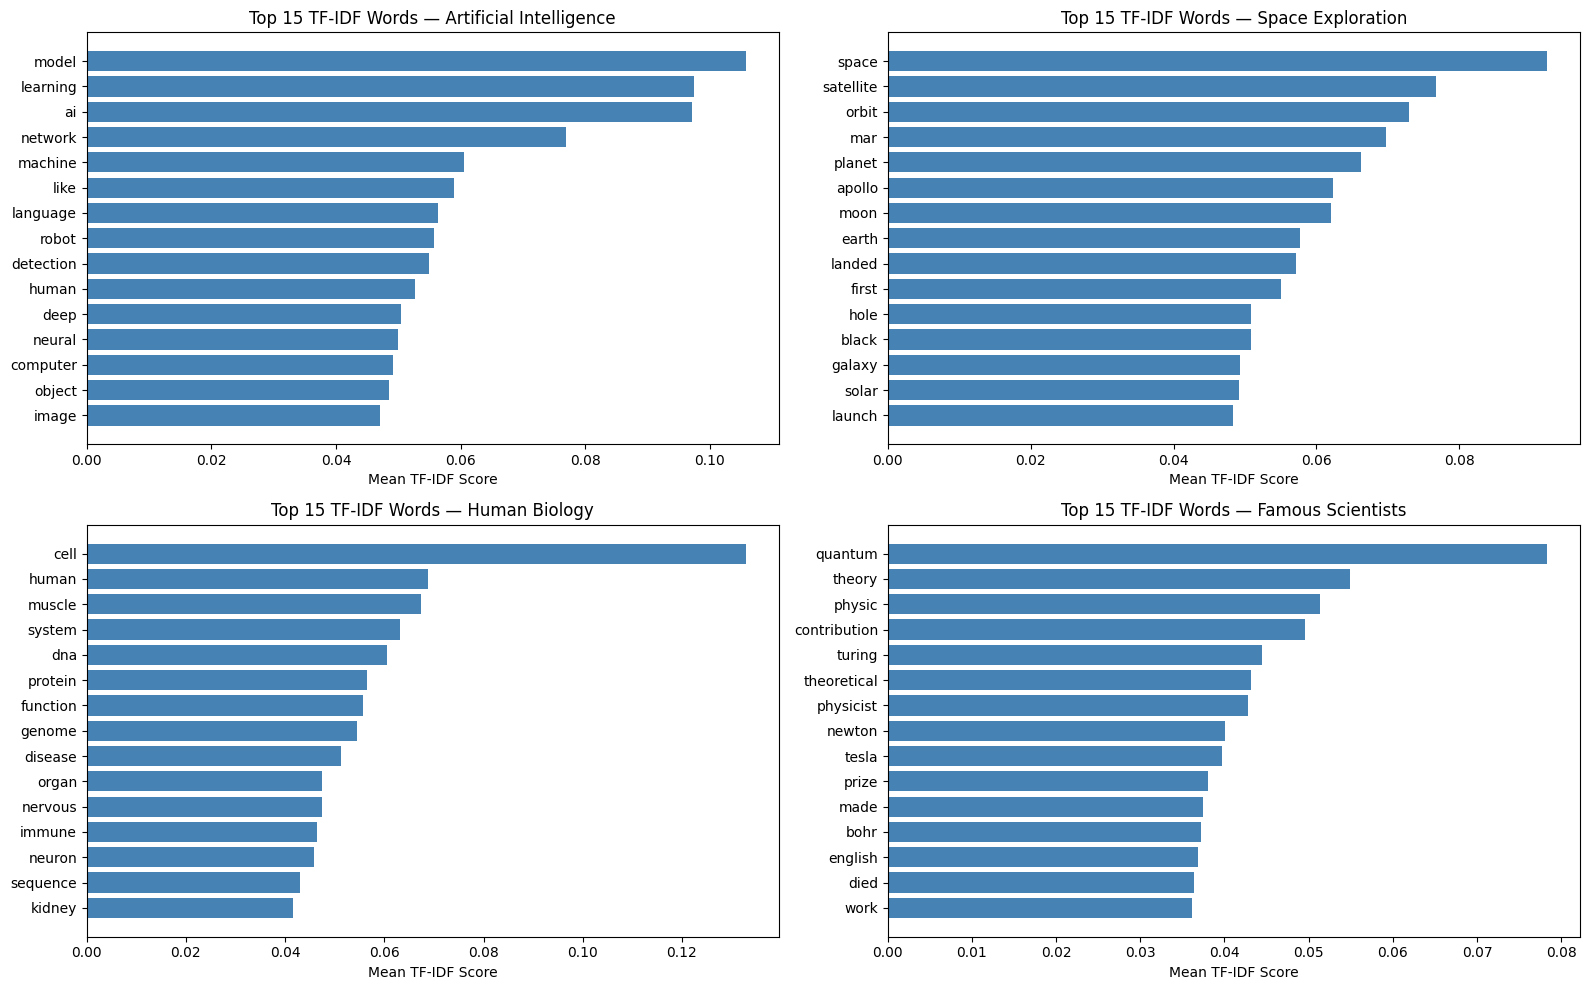

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, category in enumerate(cleaned_df['label'].unique()):
    cat_indices  = [i for i, label in enumerate(y_train_list) if label == category]
    cat_matrix   = X_train_tfidf[cat_indices]
    mean_tfidf   = cat_matrix.mean(axis=0).A1
    top15_idx    = mean_tfidf.argsort()[-15:][::-1]
    top15_words  = [feature_names[i] for i in top15_idx]
    top15_scores = [mean_tfidf[i] for i in top15_idx]

    axes[idx].barh(top15_words[::-1], top15_scores[::-1], color='steelblue')
    axes[idx].set_title(f'Top 15 TF-IDF Words — {category}')
    axes[idx].set_xlabel('Mean TF-IDF Score')

plt.tight_layout()
plt.show()

# **Save final_dataset.csv**

In [43]:
final_df = cleaned_df[['clean_text', 'label']].copy()

In [44]:
final_df['word_count']        = cleaned_df['tokens_no_stop'].apply(len)
final_df['raw_token_count']   = cleaned_df['tokens'].apply(len)
final_df['stopwords_removed'] = final_df['raw_token_count'] - final_df['word_count']

In [45]:
final_df.to_csv("final_dataset.csv", index=False)

In [46]:
print(f"Shape: {final_df.shape}")

Shape: (60, 5)


In [47]:
final_df.head()

,clean_text,label,word_count,raw_token_count,stopwords_removed
0,artificial intelligence ai intelligence demons...,Artificial Intelligence,79,114,35
1,machine learning field artificial intelligence...,Artificial Intelligence,71,93,22
2,deep learning subset machine learning based ar...,Artificial Intelligence,75,97,22
3,neural network computational model inspired st...,Artificial Intelligence,69,93,24
4,natural language processing branch ai enables ...,Artificial Intelligence,77,94,17


In [49]:
from google.colab import files
files.download('raw_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
from google.colab import files
files.download('cleaned_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
from google.colab import files
files.download('final_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>